<a href="https://colab.research.google.com/github/arsalanmontazeri/Arsalan-Montazeri/blob/Airline-Loyalty-Program-(Canada)/Airline_Loyalty_Program_(Canada)ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# For displaying all of the columns in dataframes
pd.set_option('display.max_column',None)
# For data modeling
from xgboost import XGBClassifier
from xgboost import plot_importance
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
# For saving models
import pickle
import plotly.express as px
import geopandas as gpd
import json

In [2]:
loyalty=pd.read_csv('Airline Loyalty Data Dictionary.csv')
calender=pd.read_csv('Calendar.csv')
activity=pd.read_csv('Customer Flight Activity.csv')
history=pd.read_csv('Customer Loyalty History.csv')

In [3]:
history.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [4]:
activity.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0
3,100590,2018,10,0,0,0.0,512,92
4,100590,2018,2,0,0,0.0,0,0


In [5]:
history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  object 
 2   Province            16737 non-null  object 
 3   City                16737 non-null  object 
 4   Postal Code         16737 non-null  object 
 5   Gender              16737 non-null  object 
 6   Education           16737 non-null  object 
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  object 
 9   Loyalty Card        16737 non-null  object 
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  object 
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: f

In [6]:
# salary, cancellation year and cancellation month need to action to fill up the missing value as well we can make churn column

In [7]:
history.groupby('Education')['Salary'].mean().reset_index()

,Education,Salary
0,Bachelor,72451.061575
1,College,NaN
2,Doctor,178608.897820
3,High School or Below,61071.718670
4,Master,103757.848425


In [8]:
salary_map={ 'Bachelor':72451.06,
            'College':66071.71,
            'High School or Below':61071.71,
             'Doctor':178608.89,
             'Master':103757.848425}
history['Salary']=history['Salary'].fillna(history['Education'].map(salary_map))

In [9]:
history.fillna(0,inplace=True)

In [10]:
history['Churn']=history['Cancellation Year'].apply(lambda x:1 if x!=0 else 0)

In [11]:
activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392936 entries, 0 to 392935
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               392936 non-null  int64  
 1   Year                         392936 non-null  int64  
 2   Month                        392936 non-null  int64  
 3   Total Flights                392936 non-null  int64  
 4   Distance                     392936 non-null  int64  
 5   Points Accumulated           392936 non-null  float64
 6   Points Redeemed              392936 non-null  int64  
 7   Dollar Cost Points Redeemed  392936 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 24.0 MB


In [12]:
merge_df=pd.merge(history,activity,on='Loyalty Number',how='inner')

In [13]:
merge_df.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Churn,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,0.0,0.0,0,2018,7,5,11355,11355.0,0,0
1,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,0.0,0.0,0,2017,5,4,4908,4908.0,0,0
2,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,0.0,0.0,0,2017,6,4,6948,6948.0,0,0
3,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,0.0,0.0,0,2017,8,4,5516,5516.0,0,0
4,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,0.0,0.0,0,2018,4,4,4376,4376.0,0,0


In [14]:
top_pro_city=merge_df.groupby(['Province','City','Enrollment Type','Loyalty Card']).agg({'Total Flights':'sum','CLV':'mean','Churn':'count','Points Accumulated':'mean','Points Redeemed':'mean','Distance':'sum'}).reset_index()

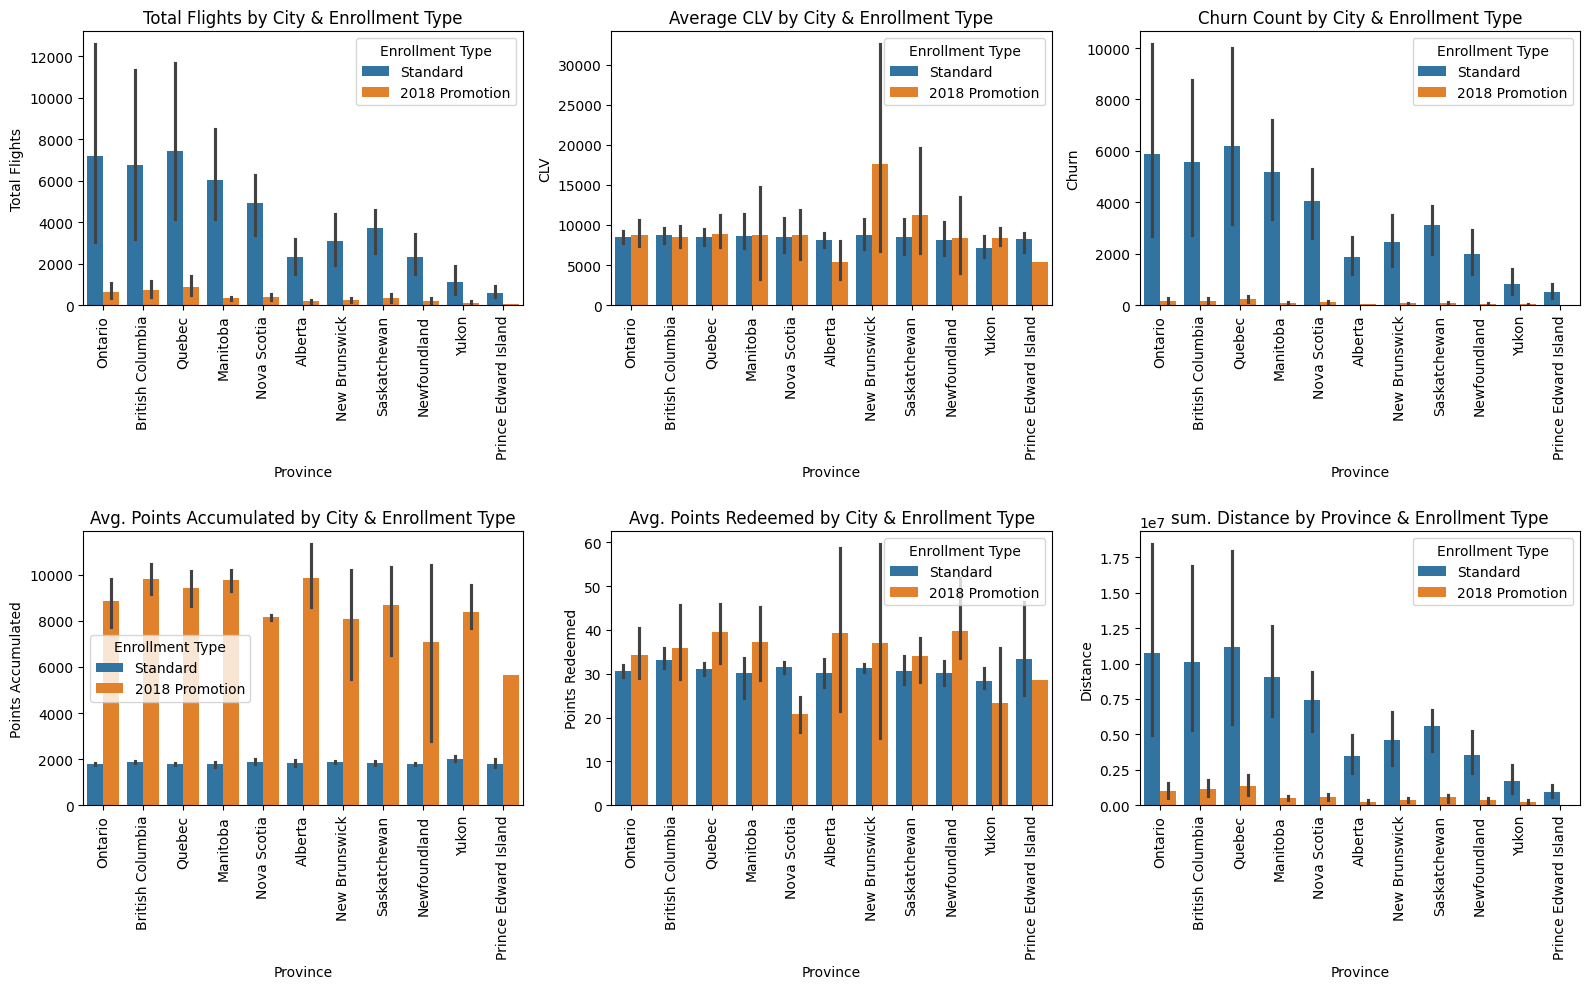

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure all columns are displayed
pd.set_option('display.max_columns', None)

# Sort by Total Flights to focus on top cities if needed
top_pro_city_sorted = top_pro_city.sort_values(by='Total Flights', ascending=False)

# Set figure size
plt.figure(figsize=(16, 10))

# 1. Total Flights by City and Enrollment Type
plt.subplot(2, 3, 1)
sns.barplot(data=top_pro_city_sorted, x='Province', y='Total Flights', hue='Enrollment Type')
plt.xticks(rotation=90)
plt.title('Total Flights by City & Enrollment Type')

# 2. Average CLV by City and Enrollment Type
plt.subplot(2, 3, 2)
sns.barplot(data=top_pro_city_sorted, x='Province', y='CLV', hue='Enrollment Type')
plt.xticks(rotation=90)
plt.title('Average CLV by City & Enrollment Type')

# 3. Churn Count by City and Enrollment Type
plt.subplot(2, 3, 3)
sns.barplot(data=top_pro_city_sorted, x='Province', y='Churn', hue='Enrollment Type')
plt.xticks(rotation=90)
plt.title('Churn Count by City & Enrollment Type')

# 4. Points Accumulated by City and Enrollment Type
plt.subplot(2, 3, 4)
sns.barplot(data=top_pro_city_sorted, x='Province', y='Points Accumulated', hue='Enrollment Type')
plt.xticks(rotation=90)
plt.title('Avg. Points Accumulated by City & Enrollment Type')

# 5. Points Redeemed by City and Enrollment Type
plt.subplot(2, 3, 5)
sns.barplot(data=top_pro_city_sorted, x='Province', y='Points Redeemed', hue='Enrollment Type')
plt.xticks(rotation=90)
plt.title('Avg. Points Redeemed by City & Enrollment Type')
#.totall distance
plt.subplot(2, 3, 6)
sns.barplot(data=top_pro_city_sorted, x='Province', y='Distance', hue='Enrollment Type')
plt.xticks(rotation=90)
plt.title('sum. Distance by Province & Enrollment Type')
plt.tight_layout()
plt.show()


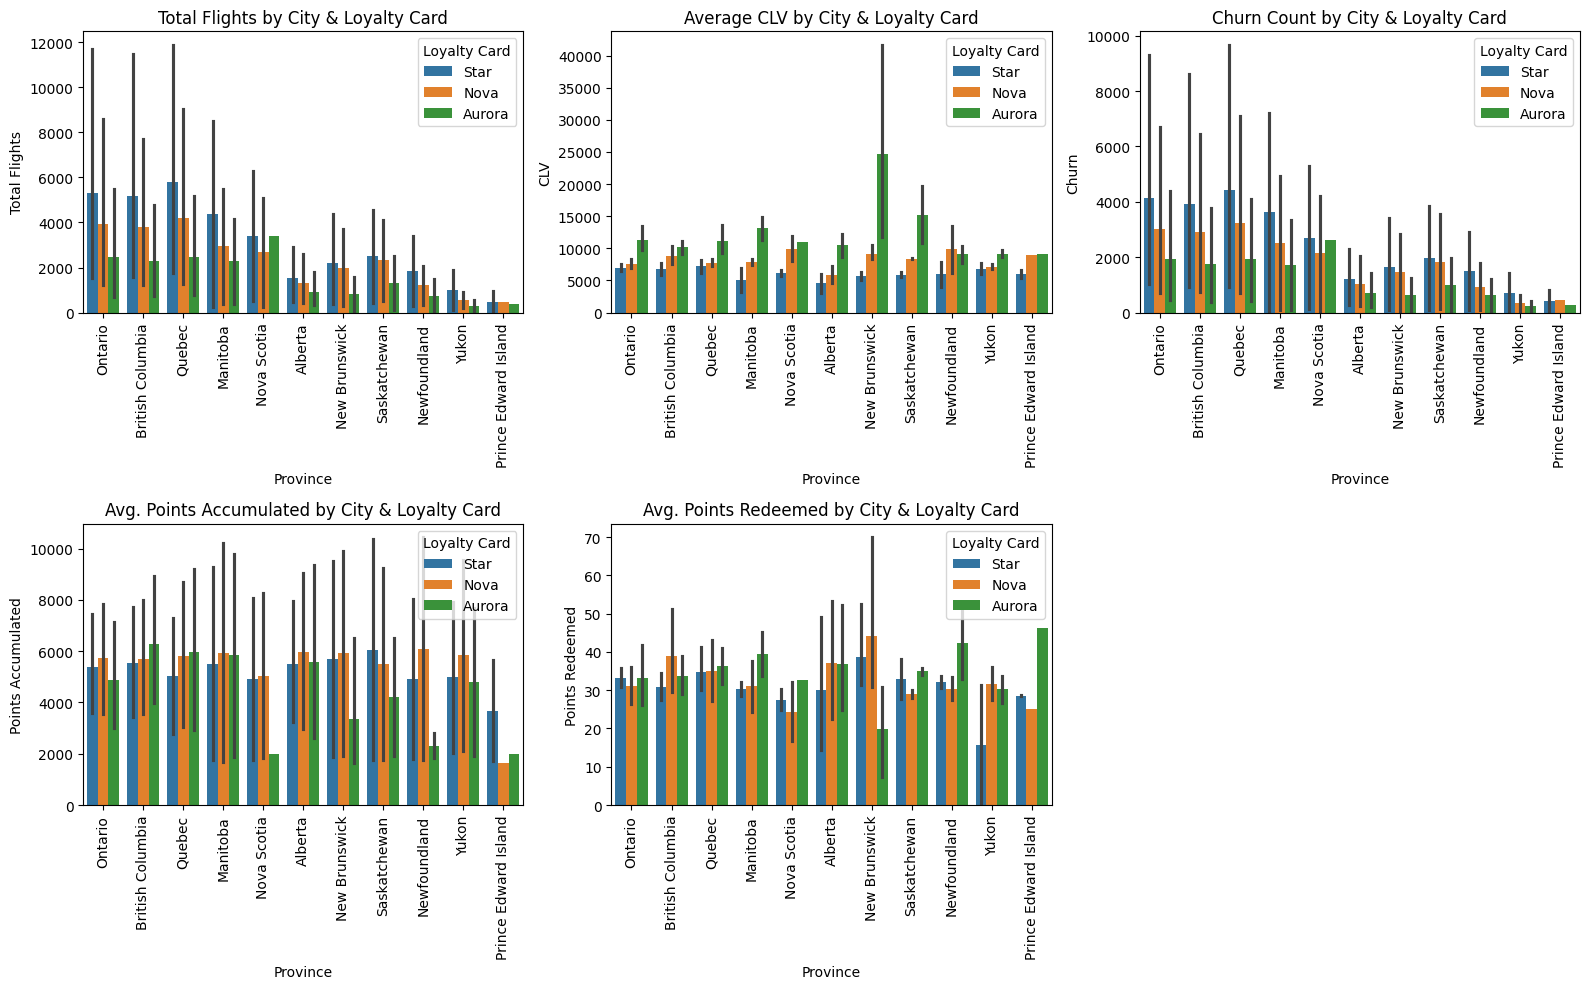

In [16]:


# Set figure size
plt.figure(figsize=(16, 10))

# 1. Total Flights by City and Enrollment Type
plt.subplot(2, 3, 1)
sns.barplot(data=top_pro_city_sorted, x='Province', y='Total Flights', hue='Loyalty Card')
plt.xticks(rotation=90)
plt.title('Total Flights by City & Loyalty Card')

# 2. Average CLV by City and Enrollment Type
plt.subplot(2, 3, 2)
sns.barplot(data=top_pro_city_sorted, x='Province', y='CLV', hue='Loyalty Card')
plt.xticks(rotation=90)
plt.title('Average CLV by City & Loyalty Card')

# 3. Churn Count by City and Enrollment Type
plt.subplot(2, 3, 3)
sns.barplot(data=top_pro_city_sorted, x='Province', y='Churn', hue='Loyalty Card')
plt.xticks(rotation=90)
plt.title('Churn Count by City & Loyalty Card')

# 4. Points Accumulated by City and Enrollment Type
plt.subplot(2, 3, 4)
sns.barplot(data=top_pro_city_sorted, x='Province', y='Points Accumulated', hue='Loyalty Card')
plt.xticks(rotation=90)
plt.title('Avg. Points Accumulated by City & Loyalty Card')

# 5. Points Redeemed by City and Enrollment Type
plt.subplot(2, 3, 5)
sns.barplot(data=top_pro_city_sorted, x='Province', y='Points Redeemed', hue='Loyalty Card')
plt.xticks(rotation=90)
plt.title('Avg. Points Redeemed by City & Loyalty Card')

plt.tight_layout()
plt.show()

In [17]:
    # Customer distribution by city
    city_stats = merge_df.groupby('City').agg({
        'CLV': 'mean',
        'Churn': 'mean',
        'Loyalty Number': 'count'
    }).reset_index()

    fig = px.scatter(city_stats, x='CLV', y='Churn',
                     size='Loyalty Number', hover_data=['City'],
                     title='city-wise Customer Value vs Churn Rate')
    fig.show()

In [18]:
Gender_analysis=merge_df.groupby(['Gender','Enrollment Type','Loyalty Card']).agg({'Total Flights':'sum','CLV':'mean','Churn':'count','Points Accumulated':'mean','Points Redeemed':'mean'}).reset_index()

In [19]:
Gender_analysis

,Gender,Enrollment Type,Loyalty Card,Total Flights,CLV,Churn,Points Accumulated,Points Redeemed
0,Female,2018 Promotion,Aurora,4889,10876.537757,1177,9572.285047,40.354291
1,Female,2018 Promotion,Nova,7577,7842.164759,1826,9464.932640,38.399781
2,Female,2018 Promotion,Star,10098,6952.617982,2453,9092.301060,31.829189
3,Female,Standard,Aurora,47349,10716.830881,39240,1818.613889,31.489348
4,Female,Standard,Nova,79757,8038.958084,66000,1811.245879,31.002167
5,Female,Standard,Star,104402,6723.299498,86496,1803.095137,31.232034
6,Male,2018 Promotion,Aurora,4617,10529.979238,1155,9027.789610,32.096104
7,Male,2018 Promotion,Nova,8106,7677.655879,1815,10055.492562,34.948760
8,Male,2018 Promotion,Star,9590,7062.284476,2310,9320.761688,34.301299
9,Male,Standard,Aurora,48085,10614.245043,39504,1839.933475,31.297210


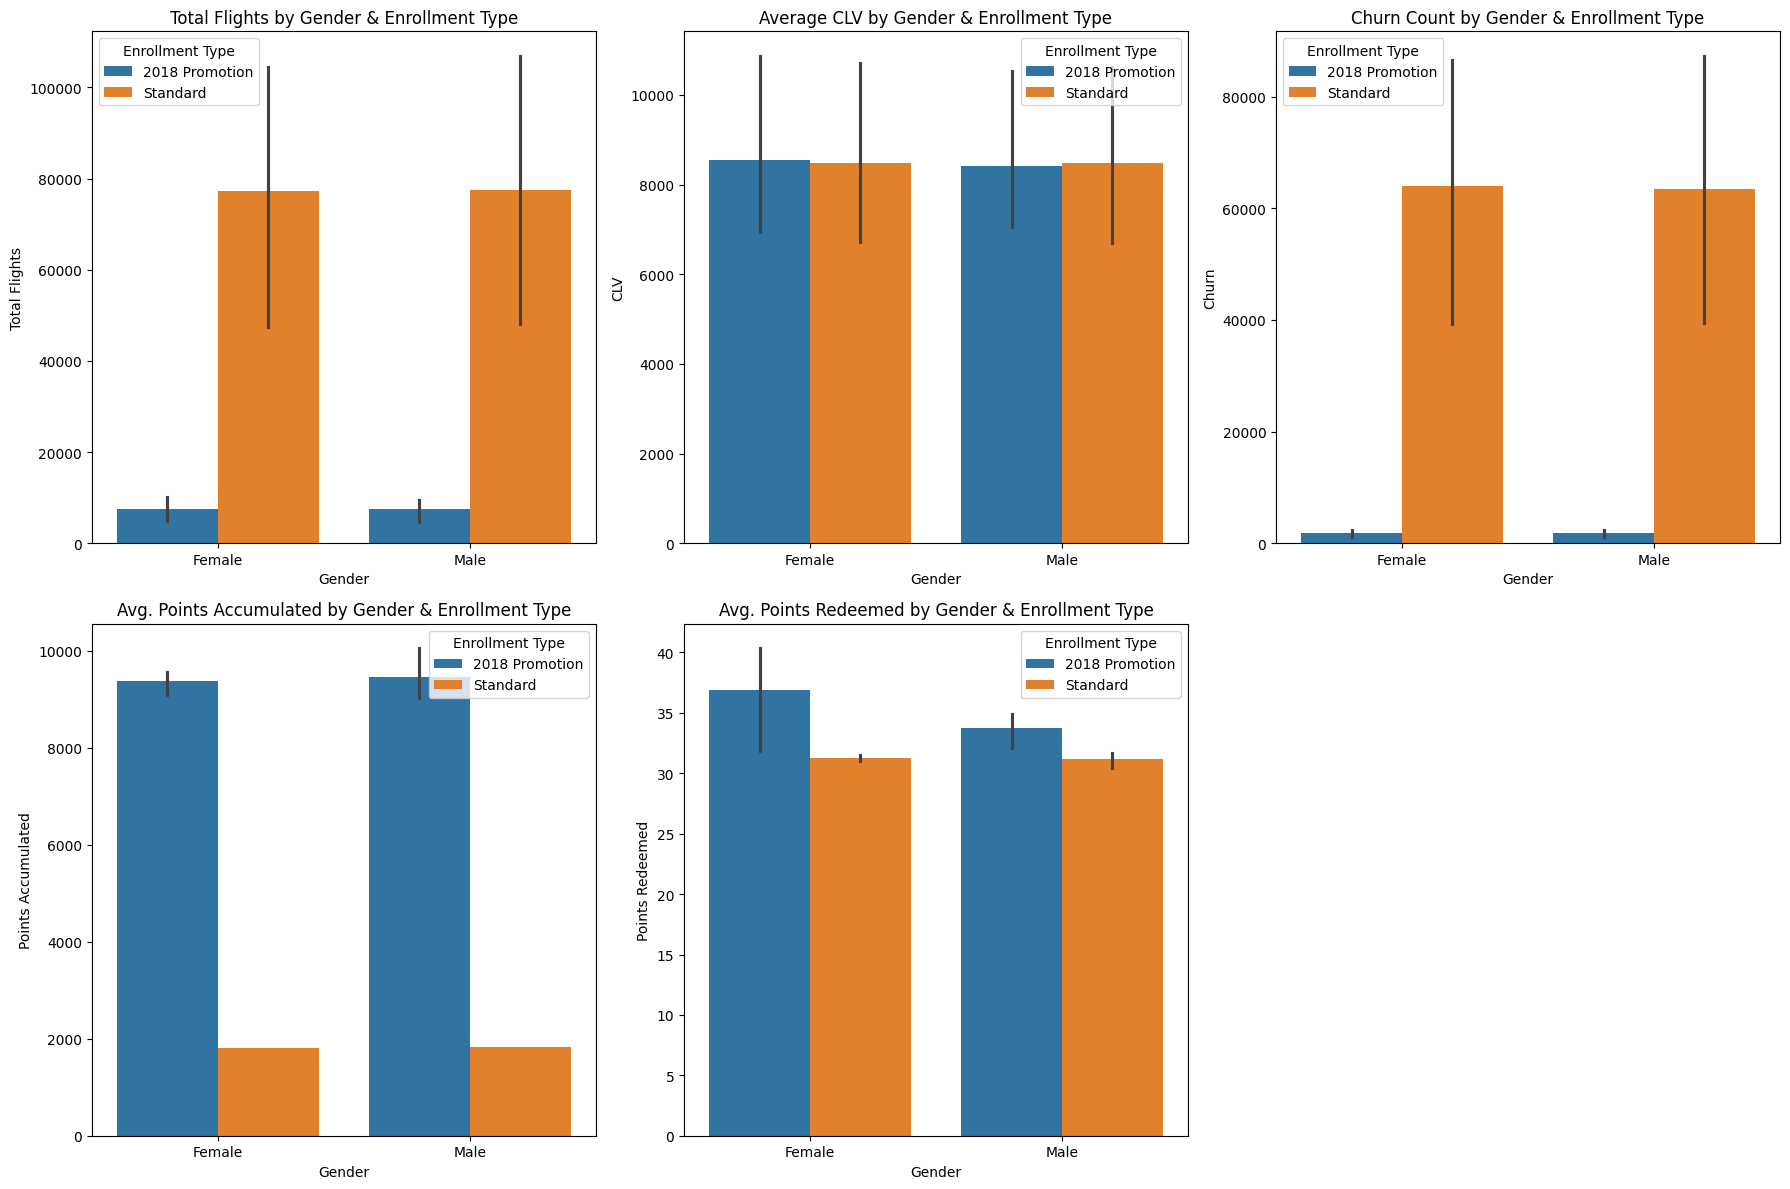

In [20]:


# Set the figure size
plt.figure(figsize=(18, 12))

# 1. Total Flights by Gender and Enrollment Type
plt.subplot(2, 3, 1)
sns.barplot(data=Gender_analysis, x='Gender', y='Total Flights', hue='Enrollment Type')
plt.title('Total Flights by Gender & Enrollment Type')

# 2. Average CLV by Gender and Enrollment Type
plt.subplot(2, 3, 2)
sns.barplot(data=Gender_analysis, x='Gender', y='CLV', hue='Enrollment Type')
plt.title('Average CLV by Gender & Enrollment Type')

# 3. Churn Count by Gender and Enrollment Type
plt.subplot(2, 3, 3)
sns.barplot(data=Gender_analysis, x='Gender', y='Churn', hue='Enrollment Type')
plt.title('Churn Count by Gender & Enrollment Type')

# 4. Avg. Points Accumulated by Gender and Enrollment Type
plt.subplot(2, 3, 4)
sns.barplot(data=Gender_analysis, x='Gender', y='Points Accumulated', hue='Enrollment Type')
plt.title('Avg. Points Accumulated by Gender & Enrollment Type')

# 5. Avg. Points Redeemed by Gender and Enrollment Type
plt.subplot(2, 3, 5)
sns.barplot(data=Gender_analysis, x='Gender', y='Points Redeemed', hue='Enrollment Type')
plt.title('Avg. Points Redeemed by Gender & Enrollment Type')

plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Churn Count by Gender & Loyalty Card')

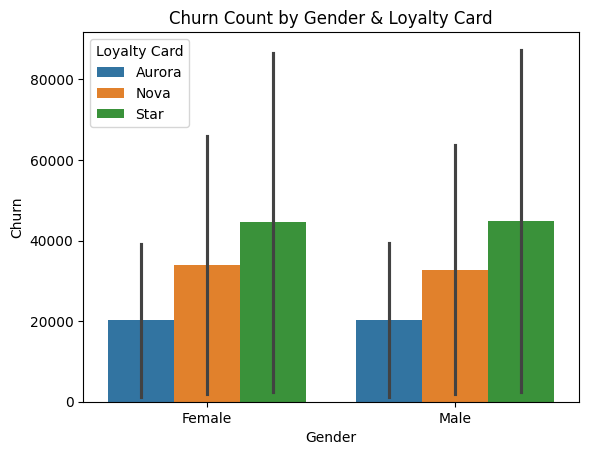

In [21]:
sns.barplot(data=Gender_analysis, x='Gender', y='Churn', hue='Loyalty Card')
plt.title('Churn Count by Gender & Loyalty Card')

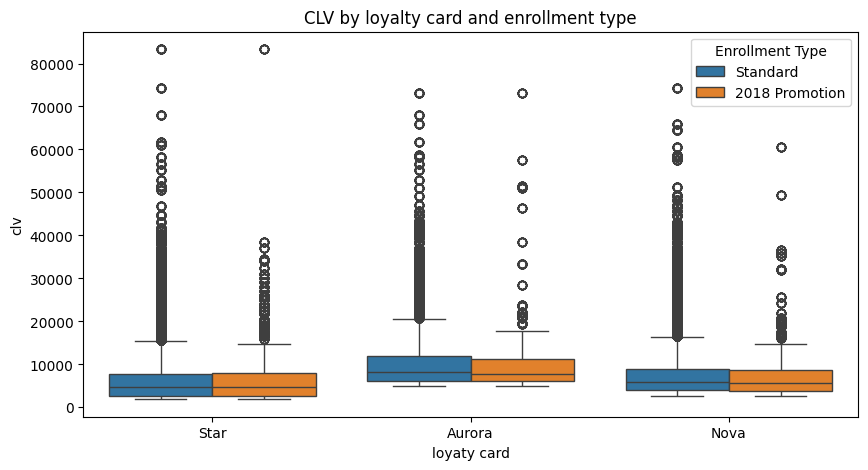

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(data=merge_df,x='Loyalty Card',y='CLV',hue='Enrollment Type')
plt.title('CLV by loyalty card and enrollment type')
plt.xlabel('loyaty card')
plt.ylabel('clv')
plt.show()

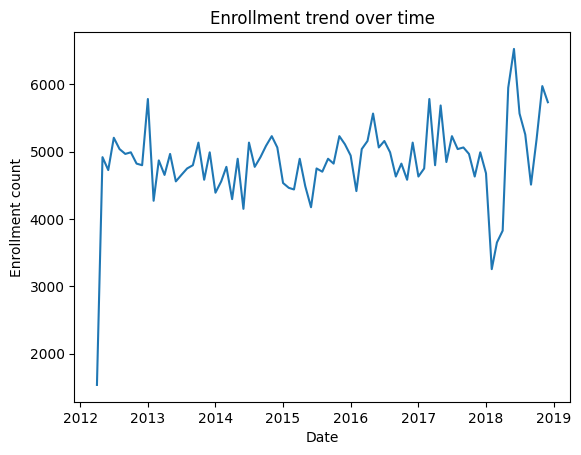

In [23]:
enrollment_trend=merge_df.groupby(['Enrollment Year','Enrollment Month','Enrollment Type']).size().reset_index(name='enrollment_count')
enrollment_trend=enrollment_trend.rename(columns={'Enrollment Year':'Year','Enrollment Month':'Month'})
enrollment_trend['Date']=pd.to_datetime(enrollment_trend[['Year','Month']].assign(day=1))
sns.lineplot(data=enrollment_trend,x='Date',y='enrollment_count')
plt.title('Enrollment trend over time')
plt.xlabel('Date')
plt.ylabel('Enrollment count')
plt.show()

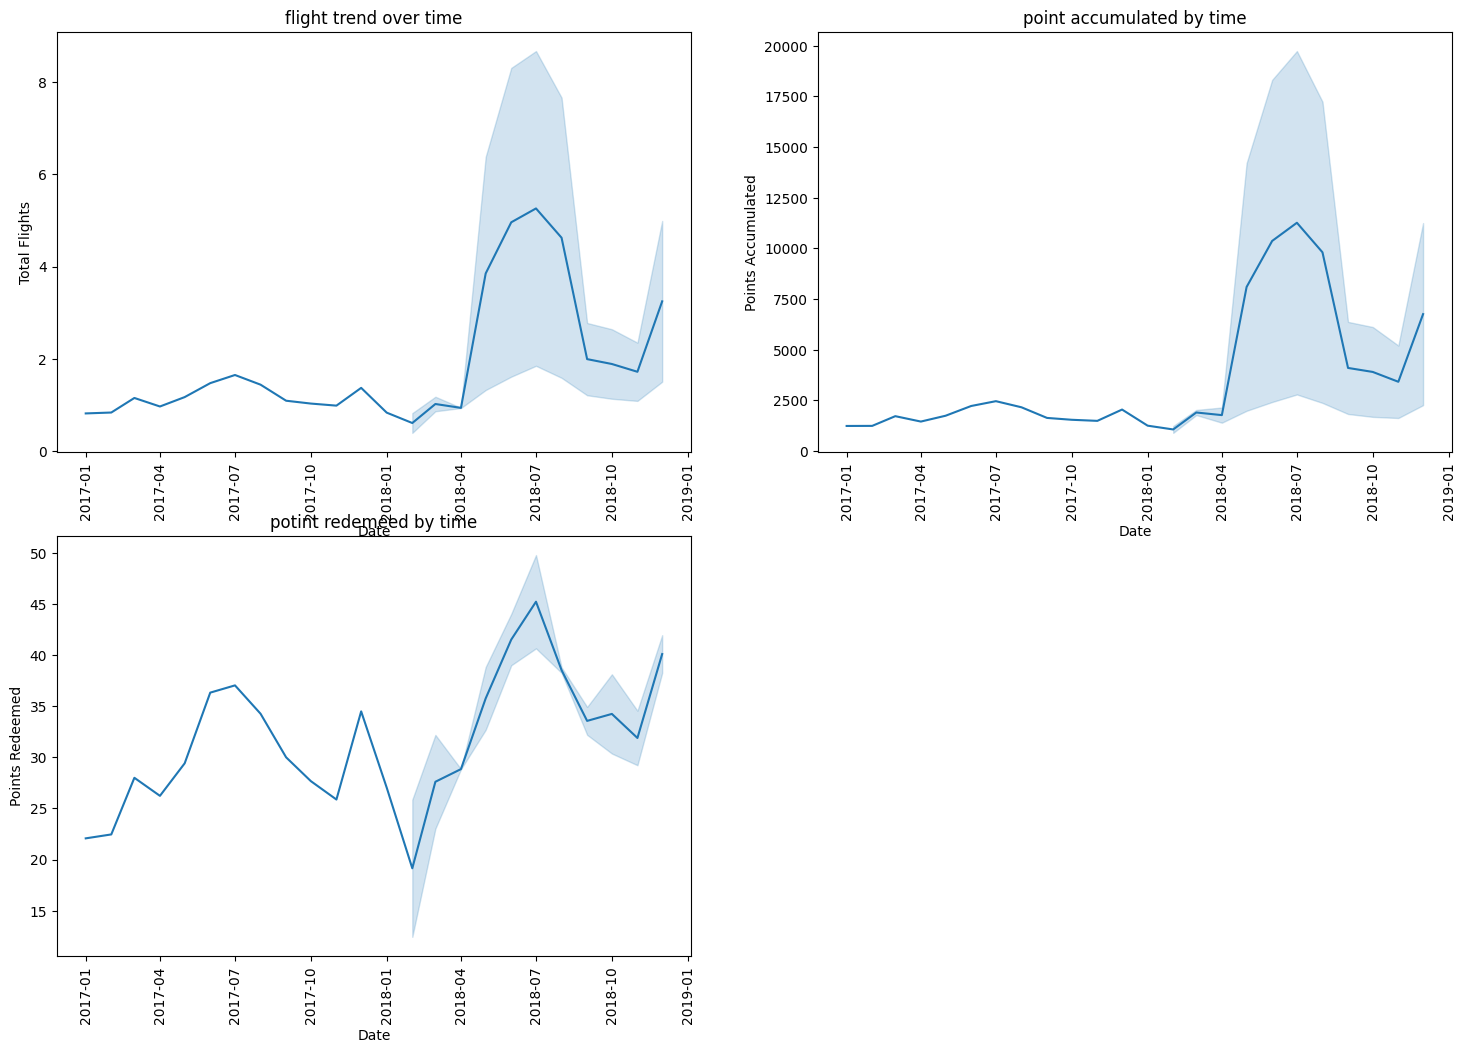

In [24]:
# %%
flight_trend=merge_df.groupby(['Year','Month','Enrollment Type']).agg({'Total Flights':'mean','Points Accumulated':'mean','Points Redeemed':'mean'}).reset_index()
flight_trend['Date']=pd.to_datetime(flight_trend[['Year','Month']].assign(day=1))
plt.figure(figsize=(18,12))
plt.subplot(2,2,1)
# Changed 'totall flight' to 'Total Flights' to match the column name in the DataFrame
sns.lineplot(data=flight_trend,x='Date',y='Total Flights')
plt.title('flight trend over time')
plt.xticks(rotation=90)
plt.subplot(2,2,2)
sns.lineplot(data=flight_trend,x='Date',y='Points Accumulated')
plt.title('point accumulated by time')
plt.xticks(rotation=90)
plt.subplot(2,2,3)
sns.lineplot(data=flight_trend,x='Date',y='Points Redeemed')
plt.title('potint redemeed by time')
plt.xticks(rotation=90)
plt.show()

Text(0.5, 1.0, 'churn trend by loyalty card')

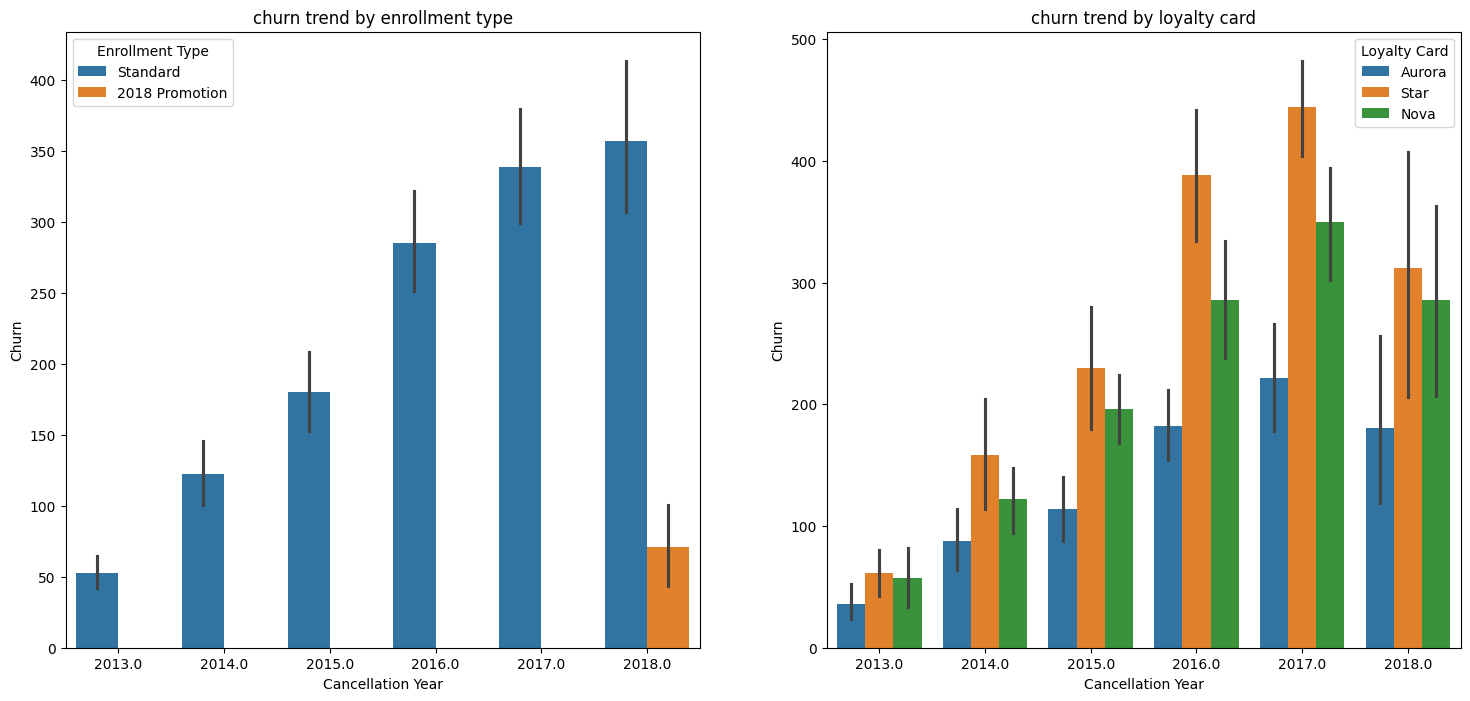

In [25]:
churn_trend=merge_df.groupby(['Cancellation Year','Cancellation Month','Enrollment Type','Loyalty Card'])['Churn'].sum().reset_index()
churn_trend=churn_trend[churn_trend['Churn']!=0]
plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
sns.barplot(data=churn_trend,x='Cancellation Year',y='Churn',hue='Enrollment Type')
plt.title('churn trend by enrollment type')
plt.subplot(1,2,2)
sns.barplot(data=churn_trend,x='Cancellation Year',y='Churn',hue='Loyalty Card')
plt.title('churn trend by loyalty card')

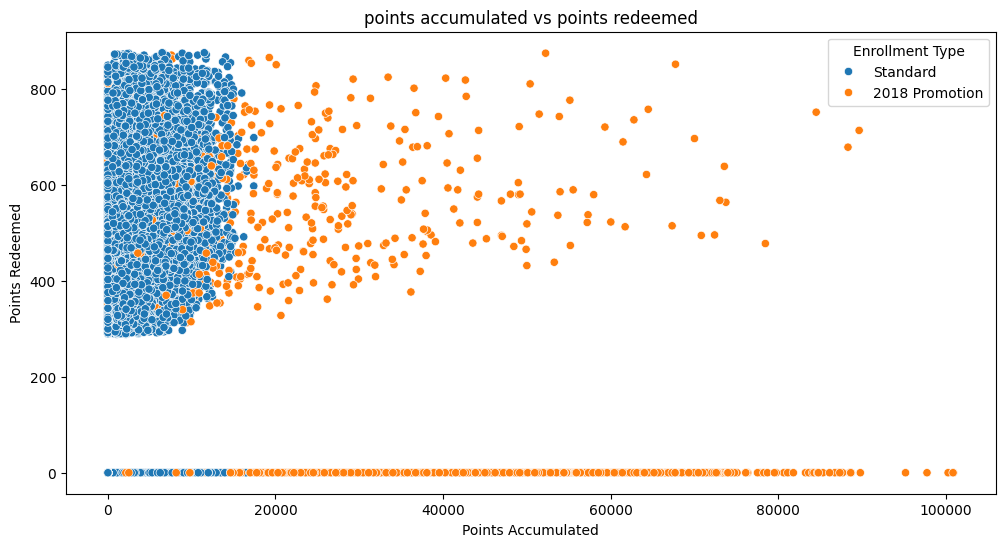

In [26]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=merge_df,x='Points Accumulated',y='Points Redeemed',hue='Enrollment Type')
plt.title('points accumulated vs points redeemed')
plt.show()


In [27]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
def churn_analysis(merge_df):
  fig=make_subplots(rows=2,cols=2,subplot_titles=('Churn by Education', 'Churn by Loyalty Card',
                                                       'Churn by Gender', 'Churn by Marital Status'))
  churn_edu=merge_df.groupby('Education')['Churn'].mean().reset_index()
  fig.add_trace(go.Bar(x=churn_edu['Education'], y=churn_edu['Churn']), row=1, col=1)
  churn_card=merge_df.groupby('Loyalty Card')['Churn'].mean().reset_index()
  fig.add_trace(go.Bar(x=churn_card['Loyalty Card'], y=churn_card['Churn']), row=1, col=2)
  churn_gender = merge_df.groupby('Gender')['Churn'].mean().reset_index()
  fig.add_trace(go.Bar(x=churn_gender['Gender'], y=churn_gender['Churn']), row=2, col=1)
  churn_marital = merge_df.groupby('Marital Status')['Churn'].mean().reset_index()
  fig.add_trace(go.Bar(x=churn_marital['Marital Status'], y=churn_marital['Churn']), row=2, col=2)
  fig.update_layout(height=700, width=900, title_text='Churn Pattern Analysis')
  fig.show()

In [28]:
churn_analysis(merge_df)

Text(0.5, 1.0, 'clv by Gender')

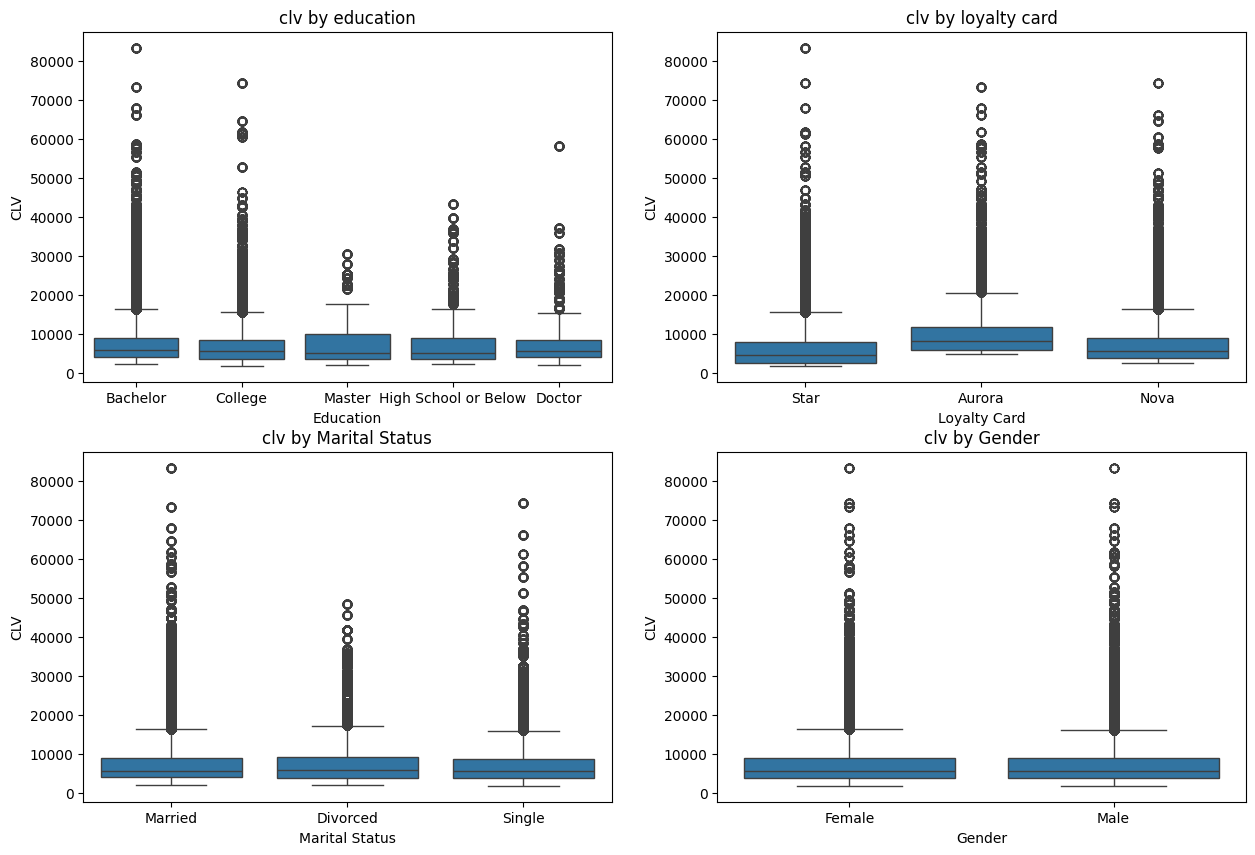

In [29]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.boxplot(data=merge_df,x='Education',y='CLV')
plt.title('clv by education')

plt.subplot(2,2,2)
sns.boxplot(data=merge_df,x='Loyalty Card',y='CLV')
plt.title('clv by loyalty card')

plt.subplot(2,2,3)
sns.boxplot(data=merge_df,x='Marital Status',y='CLV')
plt.title('clv by Marital Status')

plt.subplot(2,2,4)
sns.boxplot(data=merge_df,x='Gender',y='CLV')
plt.title('clv by Gender')

In [30]:
merge_df['CLV_segment']=pd.qcut(merge_df['CLV'],q=4,labels=['Low','Medium','High','Premium'])

In [31]:
def clv_analysis(merge_df):
  fig=px.scatter(merge_df,x='Points Accumulated',y='Points Redeemed',
                 color='CLV_segment',size='Total Flights',
                 title='Points Accumulation vs Redemption Patterns by Customer Value',
                 labels={'Points Accumulated': 'Points Accumulated',
                           'Points Redeemed': 'Points Redeemed',
                           'CLV_Segment': 'Customer Value Segment'})
  fig.show()

In [32]:
clv_analysis(merge_df)

In [33]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [34]:
df=merge_df.copy()

In [35]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Country', 'Province', 'City', 'Gender', 'Education',
            'Marital Status', 'Loyalty Card', 'Enrollment Type', 'CLV_segment']

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])


In [36]:
df['Tenure_Months'] = (
    (df['Year'] - df['Enrollment Year']) * 12 +
    (df['Month'] - df['Enrollment Month'])
)

df['Points_Utilization_Rate'] = (
    df['Points Redeemed'] / (df['Points Accumulated'] + 1)
)

df['Avg_Distance_per_Flight'] = (
    df['Distance'] / (df['Total Flights'] + 1)
)

df['Redemption_Value_per_Point'] = (
    df['Dollar Cost Points Redeemed'] / (df['Points Redeemed'] + 1)
)


In [37]:
drop_cols = ['Loyalty Number', 'City', 'Province', 'Postal Code', 'Country',
             'Enrollment Year', 'Enrollment Month',
             'Cancellation Year', 'Cancellation Month']
df = df.drop(columns=drop_cols)

In [38]:
X=df.drop(columns='Churn')
y=df['Churn']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE

In [39]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [40]:
scale_pos_weight= 341538/48450
# 8. Define XGBoost model (base)
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

# 9. Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

random_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_res, y_train_res)

print("Best hyperparameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[20:43:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




Best hyperparameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.6}


In [41]:
best_model = random_search.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]

# 11. Apply threshold based on business need
# For example, set threshold between 0.25 and 0.4
threshold = 0.84 # change as needed: 0.25, 0.3, 0.35, 0.4
y_pred = (y_proba >= threshold).astype(int)

# 12. Evaluation
print(f"\nUsing threshold: {threshold}\n")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))


Using threshold: 0.84

Confusion Matrix:
 [[63019  5858]
 [ 2809  6902]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.91      0.94     68877
           1       0.54      0.71      0.61      9711

    accuracy                           0.89     78588
   macro avg       0.75      0.81      0.77     78588
weighted avg       0.91      0.89      0.90     78588

ROC AUC Score: 0.9229284834557093


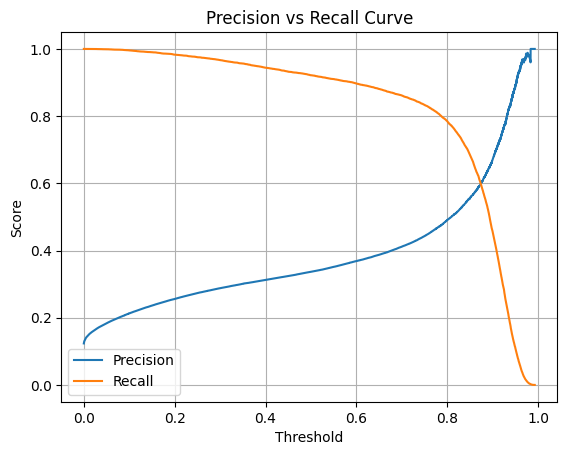

In [42]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Plot precision vs recall
import matplotlib.pyplot as plt
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall Curve')
plt.legend()
plt.grid()
plt.show()

In [43]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

# y_test: actual labels (0 or 1)
# y_probs: predicted probabilities for class 1 (e.g., model.predict_proba(X_test)[:, 1])

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Compute F1 for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

# Find the best threshold
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.4f}")


Best Threshold: 0.84
Best F1-score: 0.6158


In [44]:
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392936 entries, 0 to 392935
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   Loyalty Number               392936 non-null  int64   
 1   Country                      392936 non-null  object  
 2   Province                     392936 non-null  object  
 3   City                         392936 non-null  object  
 4   Postal Code                  392936 non-null  object  
 5   Gender                       392936 non-null  object  
 6   Education                    392936 non-null  object  
 7   Salary                       392936 non-null  float64 
 8   Marital Status               392936 non-null  object  
 9   Loyalty Card                 392936 non-null  object  
 10  CLV                          392936 non-null  float64 
 11  Enrollment Type              392936 non-null  object  
 12  Enrollment Year              392936 non-null

In [45]:
segment_profile=merge_df.groupby('CLV_segment').agg({'Salary': 'mean',
    'Total Flights': 'mean',
    'Distance': 'mean',
    'Points Accumulated': 'mean',
    'Points Redeemed': 'mean',
    'Churn': 'mean'}).reset_index()

<ipython-input-45-3430509785>:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [46]:
segment_profile

,CLV_segment,Salary,Total Flights,Distance,Points Accumulated,Points Redeemed,Churn
0,Low,76459.735329,1.293451,1933.564820,2014.148364,31.108350,0.118679
1,Medium,75682.882903,1.287198,1932.448309,2015.012024,31.530880,0.128266
2,High,77613.970388,1.298872,1951.280675,2047.104375,31.555966,0.123046
3,Premium,74685.942103,1.300030,1948.468466,2032.424259,31.021793,0.124301


In [48]:
pd.crosstab(merge_df['CLV_segment'], merge_df['Gender'], normalize='index') * 100


Gender,Female,Male
CLV_segment,,
Low,50.310894,49.689106
Medium,50.441874,49.558126
High,49.571527,50.428473
Premium,50.412945,49.587055


In [50]:
merge_df['Utilization Rate'] = merge_df['Points Redeemed'] / (merge_df['Points Accumulated'] + 1)
engagement_summary = merge_df.groupby('Enrollment Type').agg({
    'Utilization Rate': 'mean',
    'Total Flights': 'mean',
    'Churn': 'mean'
}).sort_values(by='Utilization Rate', ascending=False)
engagement_summary

,Utilization Rate,Total Flights,Churn
Enrollment Type,,,
2018 Promotion,4.414138,4.180048,0.118852
Standard,3.695316,1.213844,0.123705


In [54]:
utilization_by_segment = merge_df.groupby('CLV_segment')[['Utilization Rate', 'Churn']].mean().reset_index()
utilization_by_segment

<ipython-input-54-4276714991>:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,CLV_segment,Utilization Rate,Churn
0,Low,3.936719,0.118679
1,Medium,3.777565,0.128266
2,High,3.696969,0.123046
3,Premium,3.448413,0.124301


In [57]:
# Create strategy flags using refined thresholds
def redemption_strategy(row):
    if row['Points Accumulated'] > 10000 and row['Points Redeemed'] < 100:
        return 'Low Engagement Risk'
    elif row['Points Redeemed'] > 300 and row['CLV'] < 4000:
        return 'Profitability Leak'
    elif row['CLV'] > 12000 and row['Points Redeemed'] < 50:
        return 'Under-Incentivized VIP'
    else:
        return 'Normal'

# Apply strategy
merge_df['Redemption Strategy Tag'] = merge_df.apply(redemption_strategy, axis=1)

# Count customers in each segment
strategy_counts = merge_df['Redemption Strategy Tag'].value_counts()
print(strategy_counts)


Redemption Strategy Tag
Normal                    321464
Under-Incentivized VIP     57271
Low Engagement Risk         8274
Profitability Leak          5927
Name: count, dtype: int64


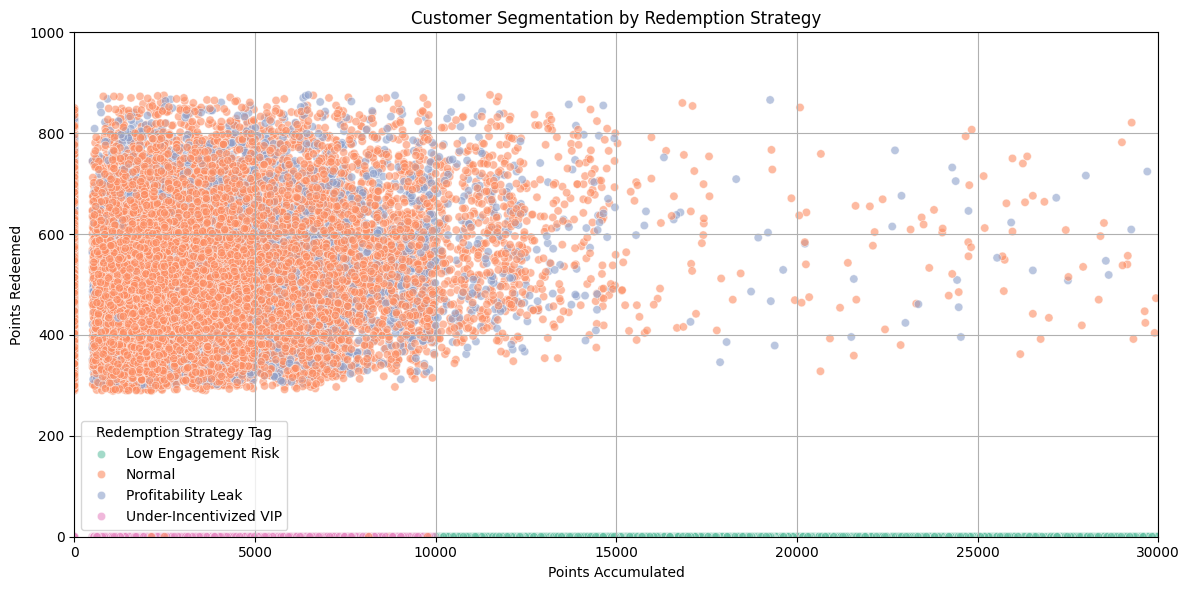

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.scatterplot(data=merge_df,
                x='Points Accumulated',
                y='Points Redeemed',
                hue='Redemption Strategy Tag',
                alpha=0.6,
                palette='Set2')

plt.title('Customer Segmentation by Redemption Strategy')
plt.xlabel('Points Accumulated')
plt.ylabel('Points Redeemed')
plt.xlim(0, 30000)   # Zoomed view for clarity
plt.ylim(0, 1000)
plt.grid(True)
plt.tight_layout()
plt.show()


In [59]:
merge_df['Redemption Rate'] = merge_df['Points Redeemed'] / (merge_df['Points Accumulated'] + 1)
merge_df['Cost per Point Redeemed'] = merge_df['Dollar Cost Points Redeemed'] / (merge_df['Points Redeemed'] + 1)
